## Analysis and Results

##### This can be used as a baseline to validate this solution

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
df = pd.read_csv("jira_m2_accelerated.csv")

In [107]:
summary = (
    df.groupby('assignee_id')
      .agg(
          num_tickets=('assignee_id', 'count'),
          total_hours=('time_to_resolution_hours', 'sum')
      )
      .reset_index()
)

# Add z-score normalization column for total_hours
summary['total_hours_z'] = (summary['total_hours'] - summary['total_hours'].mean()) / summary['total_hours'].std()

# Sort by total_hours descending if needed
summary = summary.sort_values(by='total_hours', ascending=False)

summary

,assignee_id,num_tickets,total_hours,total_hours_z
150,151,22,1509.26,3.352432
92,93,18,1322.04,2.557476
20,21,16,1314.07,2.523634
102,103,16,1219.71,2.122972
177,178,17,1218.12,2.116220
...,...,...,...,...
54,55,4,290.28,-1.823487
103,104,4,269.75,-1.910660
74,75,3,268.10,-1.917666
64,65,3,232.67,-2.068105


In [108]:
summary.describe()

,assignee_id,num_tickets,total_hours,total_hours_z
count,200.000000,200.000000,200.000000,2.000000e+02
mean,100.500000,10.000000,719.729200,4.263256e-16
std,57.879185,3.229886,235.509884,1.000000e+00
min,1.000000,3.000000,216.950000,-2.134854e+00
25%,50.750000,8.000000,537.187500,-7.750915e-01
50%,100.500000,10.000000,721.805000,8.814067e-03
75%,150.250000,12.000000,885.687500,7.046766e-01
max,200.000000,22.000000,1509.260000,3.352432e+00


In [109]:
max_workload = summary['total_hours'].max()
mean_workload = summary['total_hours'].mean()
std_workload = summary['total_hours'].std()

print(f"Max workload (L_max): {max_workload:.2f} hours")
print(f"Average workload: {mean_workload:.2f} hours")
print(f"Std deviation: {std_workload:.2f} hours")

Max workload (L_max): 1509.26 hours
Average workload: 719.73 hours
Std deviation: 235.51 hours


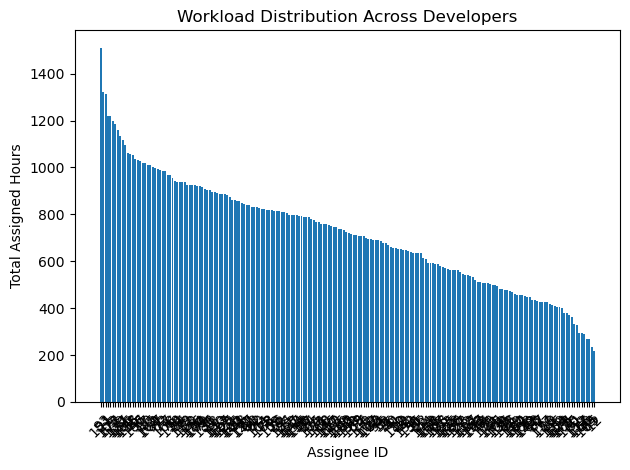

In [110]:
# Bar chart of total hours per developer
plt.figure()
plt.bar(summary['assignee_id'].astype(str), summary['total_hours'])
plt.xlabel('Assignee ID')
plt.ylabel('Total Assigned Hours')
plt.title('Workload Distribution Across Developers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

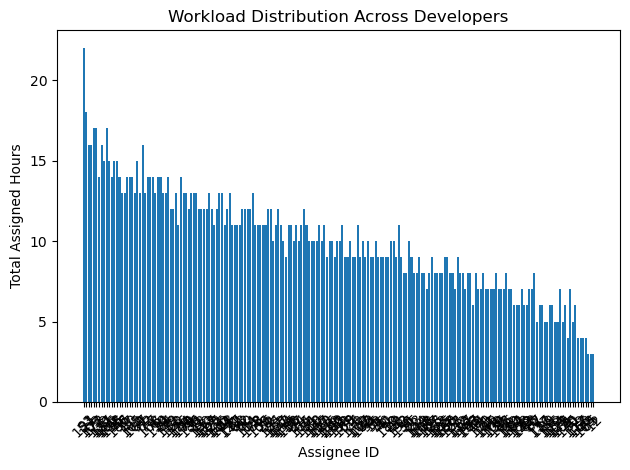

In [111]:
import matplotlib.pyplot as plt

# Bar chart of total hours per developer
plt.figure()
plt.bar(summary['assignee_id'].astype(str), summary['num_tickets'])
plt.xlabel('Assignee ID')
plt.ylabel('Total Assigned Hours')
plt.title('Workload Distribution Across Developers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Simulation Results

In [112]:
# results from Sprint 1 allocation
developer_data = {
    1: {"Total Assigned Hours": 93.4, "# of Allocated Tickets": 2},
    2: {"Total Assigned Hours": 93.8, "# of Allocated Tickets": 2},
    3: {"Total Assigned Hours": 52.1, "# of Allocated Tickets": 1},
    4: {"Total Assigned Hours": 85.3, "# of Allocated Tickets": 2},
    5: {"Total Assigned Hours": 86.3, "# of Allocated Tickets": 2},
    6: {"Total Assigned Hours": 55.0, "# of Allocated Tickets": 1},
    7: {"Total Assigned Hours": 75.5, "# of Allocated Tickets": 2},
    8: {"Total Assigned Hours": 84.3, "# of Allocated Tickets": 2},
    9: {"Total Assigned Hours": 51.4, "# of Allocated Tickets": 1},
    10: {"Total Assigned Hours": 57.6, "# of Allocated Tickets": 1},
    11: {"Total Assigned Hours": 56.6, "# of Allocated Tickets": 1},
    12: {"Total Assigned Hours": 94.7, "# of Allocated Tickets": 2},
    13: {"Total Assigned Hours": 53.9, "# of Allocated Tickets": 1},
    14: {"Total Assigned Hours": 52.1, "# of Allocated Tickets": 1},
    15: {"Total Assigned Hours": 93.7, "# of Allocated Tickets": 2},
    16: {"Total Assigned Hours": 91.8, "# of Allocated Tickets": 2},
    17: {"Total Assigned Hours": 50.9, "# of Allocated Tickets": 1},
    18: {"Total Assigned Hours": 54.0, "# of Allocated Tickets": 1},
    19: {"Total Assigned Hours": 90.1, "# of Allocated Tickets": 2},
    20: {"Total Assigned Hours": 57.8, "# of Allocated Tickets": 1},
}

In [113]:
# Convert developer_data dict to DataFrame
df = pd.DataFrame.from_dict(developer_data, orient='index')
df.index.name = 'developer'
df.reset_index(inplace=True)

# Rename columns for clarity
df = df.rename(columns={
    "Total Assigned Hours": "total_hours",
    "# of Allocated Tickets": "num_tickets"
})

# Add z-score normalization column for total_hours
df['total_hours_z'] = (df['total_hours'] - df['total_hours'].mean()) / df['total_hours'].std()

# Sort by total_hours descending if needed
summary_eval = df.sort_values(by="total_hours", ascending=False)

summary_eval

,developer,total_hours,num_tickets,total_hours_z
11,12,94.7,2,1.260548
1,2,93.8,2,1.211616
14,15,93.7,2,1.206179
0,1,93.4,2,1.189868
15,16,91.8,2,1.102877
18,19,90.1,2,1.010450
4,5,86.3,2,0.803847
3,4,85.3,2,0.749478
7,8,84.3,2,0.695109
6,7,75.5,2,0.216661


In [114]:
max_workload = summary_eval['total_hours'].max()
mean_workload = summary_eval['total_hours'].mean()
std_workload = summary_eval['total_hours'].std()

print(f"Max workload (L_max): {max_workload:.2f} hours")
print(f"Average workload: {mean_workload:.2f} hours")
print(f"Std deviation: {std_workload:.2f} hours")

Max workload (L_max): 94.70 hours
Average workload: 71.52 hours
Std deviation: 18.39 hours


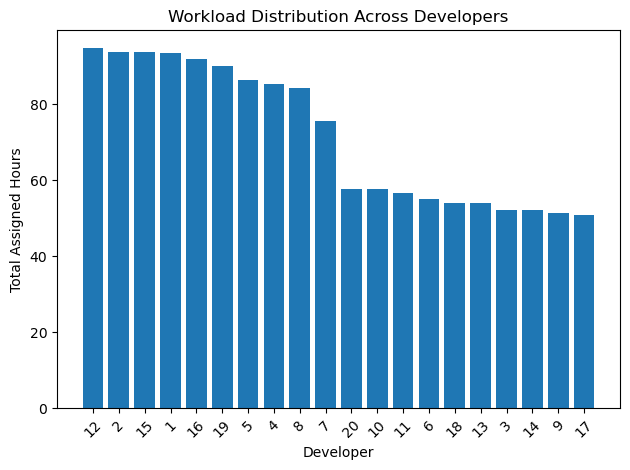

In [115]:
# Bar chart of total hours per developer
plt.figure()
plt.bar(summary_eval['developer'].astype(str), summary_eval['total_hours'])
plt.xlabel('Developer')
plt.ylabel('Total Assigned Hours')
plt.title('Workload Distribution Across Developers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

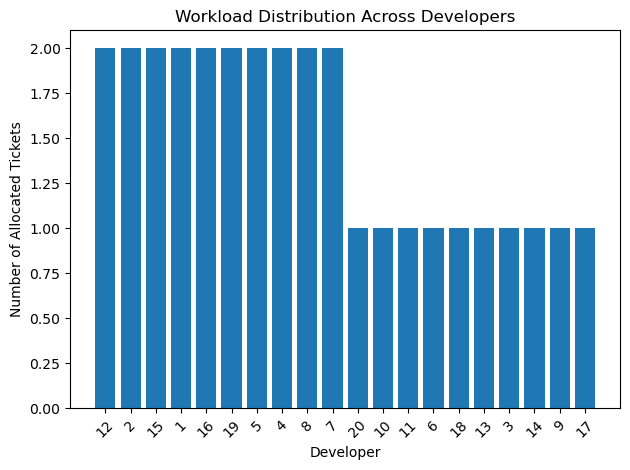

In [116]:
# Bar chart of total hours per developer
plt.figure()
plt.bar(summary_eval['developer'].astype(str), summary_eval['num_tickets'])
plt.xlabel('Developer')
plt.ylabel('Number of Allocated Tickets')
plt.title('Workload Distribution Across Developers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()